# Sales Transaction Analytics, Predictive Modeling, and Anomaly Detection Using Machine Learning

---

### Student Name

**Dharshini G**

---

### Batch

**PGA 38**

---

### Course

**Data Science With Gen AI**

---

# Executive Summary

This project presents a comprehensive analysis of sales transaction data using machine learning techniques to uncover business insights, predict future transaction amounts, and identify anomalous transactions. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, predictive modeling, model evaluation, and anomaly detection using the Isolation Forest algorithm.

The project aims to support businesses in understanding sales trends, improving forecasting accuracy, and detecting unusual transaction patterns that may indicate fraud, operational issues, or data inconsistencies. Multiple regression models, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor, are developed and evaluated to identify the most effective predictive model. The results demonstrate how machine learning can enhance data-driven decision-making and improve business performance.

---

# Project Workflow

```

                     Sales Transaction Dataset
                                │
                                ▼
                      Data Understanding
                                │
                                ▼
                 Data Cleaning & Preprocessing
                                │
                                ▼
                Exploratory Data Analysis (EDA)
                                │
                                ▼
                     Feature Engineering
                                │
                                ▼
                 Feature Selection & Scaling
                                │
                                ▼
              Predictive Model Development
          (Linear Regression, Decision Tree,
               Random Forest Regressor)
                                │
                                ▼
                    Model Evaluation
      (MAE, MSE, RMSE, R² Score Comparison)
                                │
                                ▼
             Isolation Forest Algorithm
                                │
                                ▼
                   Anomaly Detection
                                │
                                ▼
                 Business Insights & Visualization
                                │
                                ▼
                     Final Conclusion

```




## Table of Contents
- [1. Import Packages](#1.-Import-Packages)
- [2. Read Dataset](#2.-Read-Dataset)
- [3. Project Overview](#3.-Project-Overview)
- [4. Understand the Dataset](#4.-Understand-the-Dataset)
- [5. Data Preprocessing](#5.-Data-Preprocessing)
- [6. Exploratory Data Analysis](#6.-Exploratory-Data-Analysis)
- [7. Feature Engineering](#7.-Feature-Engineering)
- [8. Feature Selection](#8.-Feature-Selection)
- [9. Data Splitting](#9.-Data-Splitting)
- [10. Machine Learning Model](#10.-Machine-Learning-Model)
- [11. Model Evaluation](#11.-Model-Evaluation)
- [12. Anomaly Detection](#12.-Anomaly-Detection)
- [13. Feature Importance](#13.-Feature-Importance)
- [14. Business Insights](#14.-Business-Insights)
- [15. Save Model](#15.-Save-Model)
- [16. Conclusion](#16.-Conclusion)
- [17. Future Scope](#17.-Future-Scope)
- [18. References](#18.-References)

# 1. Import Packages

This section imports all the required libraries for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest

# Evaluation Metrics
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Save Model
import joblib

print("Libraries Imported Successfully")



Libraries Imported Successfully


In [2]:
import os
os.makedirs("Graphs", exist_ok=True)

# 2. Read Dataset

The dataset is loaded using the Pandas library.

In [3]:
df = pd.read_excel(r'C:\Users\dell\OneDrive\Desktop\Sales_Transaction_ML_Project\Dataset\Sales_Transaction.xlsx')

In [4]:
df.head()

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
0,2024-04-01,2024-04-01,TSP POS,TSP/001\24-25,12000,January,2024,Q1
1,2024-04-01,2024-04-01,TSP POS,TSP/002\24-25,5300,January,2024,Q1
2,2024-04-03,2024-04-03,TSP POS,TSP/003\24-25,14300,January,2024,Q1
3,2024-04-04,2024-04-04,TSP POS,TSP/004\24-25,11600,January,2024,Q1
4,2024-04-05,2024-04-05,TSP POS,TSP/005\24-25,4300,January,2024,Q1


In [5]:
df.tail()

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
3408,2025-03-31,2025-03-31,TSP POS,TSP/3385\24-25,9500,December,2025,Q4
3409,2025-03-31,2025-03-31,TSP POS,TSP/3386\24-25,7000,December,2025,Q4
3410,2025-03-31,2025-03-31,TSP POS,TSP/3387\24-25,7380,December,2025,Q4
3411,2025-03-31,2025-03-31,TSP POS,TSP/3388\24-25,10970,January,2026,Q1
3412,2025-03-31,2025-03-31,NaN,NaN,2193680.01,January,2026,Q1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3413 non-null   datetime64[us]
 1   TxnDate   3413 non-null   datetime64[us]
 2   Vch Type  3389 non-null   str           
 3   Vch No.   3389 non-null   str           
 4   Amount    3399 non-null   object        
 5   Month     3413 non-null   str           
 6   Year      3413 non-null   int64         
 7   Quarter   3413 non-null   str           
dtypes: datetime64[us](2), int64(1), object(1), str(4)
memory usage: 213.4+ KB


# 3. Project Overview

## Problem Statement

Businesses generate a large number of sales transactions every day.
Manually analyzing these transactions to identify sales trends,
predict future sales, and detect abnormal transactions is difficult.

This project develops a Machine Learning model that analyzes historical
sales transactions, predicts future sales, and detects anomalous
transactions using Random Forest Regression and Isolation Forest.

---

## Objectives

• Analyze historical sales transactions

• Perform Data Cleaning

• Conduct Exploratory Data Analysis (EDA)

• Perform Feature Engineering

• Predict Sales using Machine Learning

• Detect Anomalies

• Generate Business Insights

• Save the Machine Learning Model

# 4. Understand Dataset

This section provides an overview of the dataset including its structure,
data types, missing values, and statistical summary.

In [7]:
df.shape

(3413, 8)

In [8]:
df.columns

Index(['Date', 'TxnDate', 'Vch Type', 'Vch No.', 'Amount', 'Month', 'Year',
       'Quarter'],
      dtype='str')

In [9]:
df.dtypes

Date        datetime64[us]
TxnDate     datetime64[us]
Vch Type               str
Vch No.                str
Amount              object
Month                  str
Year                 int64
Quarter                str
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3413 non-null   datetime64[us]
 1   TxnDate   3413 non-null   datetime64[us]
 2   Vch Type  3389 non-null   str           
 3   Vch No.   3389 non-null   str           
 4   Amount    3399 non-null   object        
 5   Month     3413 non-null   str           
 6   Year      3413 non-null   int64         
 7   Quarter   3413 non-null   str           
dtypes: datetime64[us](2), int64(1), object(1), str(4)
memory usage: 213.4+ KB


In [11]:
df.describe(include="all")

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
count,3413,3413,3389,3389,3399.0,3413,3413.000000,3413
unique,NaN,NaN,2,3387,916.0,12,NaN,4
top,NaN,NaN,TSP POS,TSP/2024\24-25,7380.0,August,NaN,Q4
freq,NaN,NaN,3388,2,86.0,295,NaN,863
mean,2025-03-16 17:20:26.721359,2025-03-16 17:20:26.721359,NaN,NaN,NaN,NaN,2024.501025,NaN
min,2024-04-01 00:00:00,2024-04-01 00:00:00,NaN,NaN,NaN,NaN,2024.000000,NaN
25%,2025-03-31 00:00:00,2025-03-31 00:00:00,NaN,NaN,NaN,NaN,2024.000000,NaN
50%,2025-03-31 00:00:00,2025-03-31 00:00:00,NaN,NaN,NaN,NaN,2025.000000,NaN
75%,2025-03-31 00:00:00,2025-03-31 00:00:00,NaN,NaN,NaN,NaN,2025.000000,NaN
max,2025-03-31 00:00:00,2025-03-31 00:00:00,NaN,NaN,NaN,NaN,2026.000000,NaN


In [12]:
df.isnull().sum()

Date         0
TxnDate      0
Vch Type    24
Vch No.     24
Amount      14
Month        0
Year         0
Quarter      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(4)

In [14]:
df.nunique()

Date         191
TxnDate      191
Vch Type       2
Vch No.     3387
Amount       916
Month         12
Year           3
Quarter        4
dtype: int64

In [15]:
df.memory_usage(deep=True)

Index          132
Date         27304
TxnDate      27304
Vch Type    190553
Vch No.     213269
Amount      122817
Month       188210
Year         27304
Quarter     174063
dtype: int64

In [16]:
df.sample(10)

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
1402,2025-03-31,2025-03-31,TSP POS,TSP/1391\24-25,13900,October,2024,Q4
2875,2025-03-31,2025-03-31,TSP POS,TSP/2854\24-25,14300,September,2025,Q3
2,2024-04-03,2024-04-03,TSP POS,TSP/003\24-25,14300,January,2024,Q1
1515,2025-03-31,2025-03-31,TSP POS,TSP/1504\24-25,10500,November,2024,Q4
2676,2025-03-31,2025-03-31,TSP POS,TSP/2657\24-25,2400,July,2025,Q3
2338,2025-03-31,2025-03-31,TSP POS,TSP/2321\24-25,5200,May,2025,Q2
3094,2025-03-31,2025-03-31,TSP POS,TSP/3073\24-25,7900,October,2025,Q4
2177,2025-03-31,2025-03-31,TSP POS,TSP/2162\24-25,6900,April,2025,Q2
3379,2025-03-31,2025-03-31,TSP POS,TSP/3356\24-25,7890,December,2025,Q4
2955,2025-03-31,2025-03-31,TSP POS,TSP/2934\24-25,4400,September,2025,Q3


# 5. Data Preprocessing

Data preprocessing is an essential step in machine learning. It improves data quality by handling missing values, removing duplicate records, correcting data types, and preparing the dataset for analysis and model building.

In [17]:
df.isnull().sum()

Date         0
TxnDate      0
Vch Type    24
Vch No.     24
Amount      14
Month        0
Year         0
Quarter      0
dtype: int64

## 5.2 Handle Missing Values

Remove rows containing missing values. If your dataset has no missing values, this step will not change the data.

In [18]:
df = df.dropna()

print("Dataset Shape After Removing Missing Values:", df.shape)

Dataset Shape After Removing Missing Values: (3388, 8)


## 5.3 Check Duplicate Records

Identify duplicate rows in the dataset.

In [19]:
df.duplicated().sum()

np.int64(0)

## 5.4 Remove Duplicate Records

Remove duplicate records to improve data quality.

In [20]:
df = df.drop_duplicates()
df.shape

(3388, 8)

## 5.5 Convert Date Column

Convert the Date column into datetime format.

In [21]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].head()

0   2024-04-01
1   2024-04-01
2   2024-04-03
3   2024-04-04
4   2024-04-05
Name: Date, dtype: datetime64[us]

## 5.6 Verify Data Types

Verify the updated data types after preprocessing.

In [22]:
df.dtypes

Date        datetime64[us]
TxnDate     datetime64[us]
Vch Type               str
Vch No.                str
Amount              object
Month                  str
Year                 int64
Quarter                str
dtype: object

## 5.7 Rename Columns 
Rename columns if they contain spaces or special characters.

In [23]:
df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'TxnDate', 'Vch Type', 'Vch No.', 'Amount', 'Month', 'Year',
       'Quarter'],
      dtype='str')

In [24]:
print(df.columns.tolist())

['Date', 'TxnDate', 'Vch Type', 'Vch No.', 'Amount', 'Month', 'Year', 'Quarter']


In [25]:
df.head()

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
0,2024-04-01,2024-04-01,TSP POS,TSP/001\24-25,12000,January,2024,Q1
1,2024-04-01,2024-04-01,TSP POS,TSP/002\24-25,5300,January,2024,Q1
2,2024-04-03,2024-04-03,TSP POS,TSP/003\24-25,14300,January,2024,Q1
3,2024-04-04,2024-04-04,TSP POS,TSP/004\24-25,11600,January,2024,Q1
4,2024-04-05,2024-04-05,TSP POS,TSP/005\24-25,4300,January,2024,Q1


In [26]:
df["Amount"].dtype

dtype('O')

In [27]:
df["Amount"].unique()[:10]

array([12000, 5300, 14300, 11600, 4300, 7080, 5100, 7930, 8490, 7530],
      dtype=object)

In [28]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
print(df["Amount"].dtype)
print(df["Amount"].isnull().sum())

float64
1


In [29]:
df[df["Amount"].isnull()]

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter
428,2025-03-31,2025-03-31,Vch Type,Vch No.,NaN,April,2024,Q2


In [30]:
df = df.dropna(subset=["Amount"])

In [31]:
print(df["Amount"].isnull().sum())

0


In [32]:
df["Amount"] = df["Amount"].astype(int)

In [33]:
df["Amount"].dtype

dtype('int64')

## 5.8 Detect Outliers
Visualize the distribution of transaction amounts using a box plot.

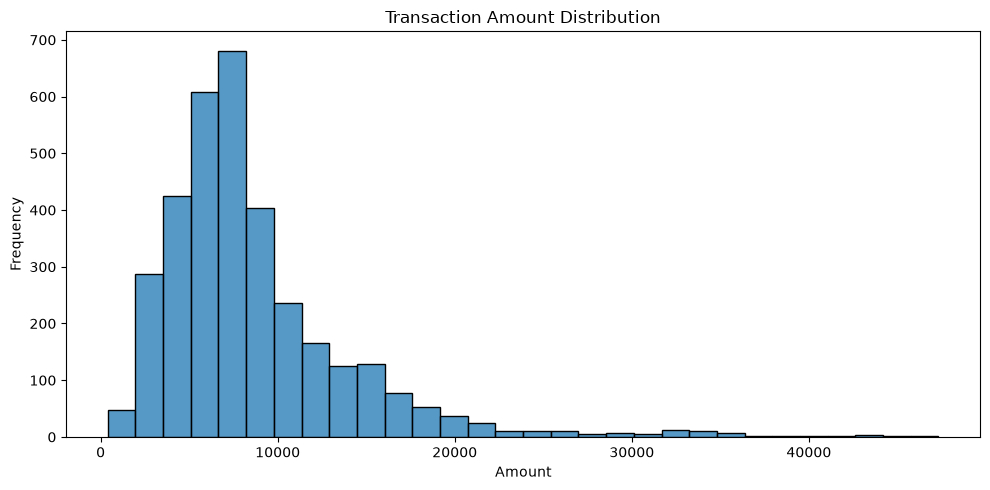

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount"], bins=30)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Graphs/01_Transaction_Amount_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

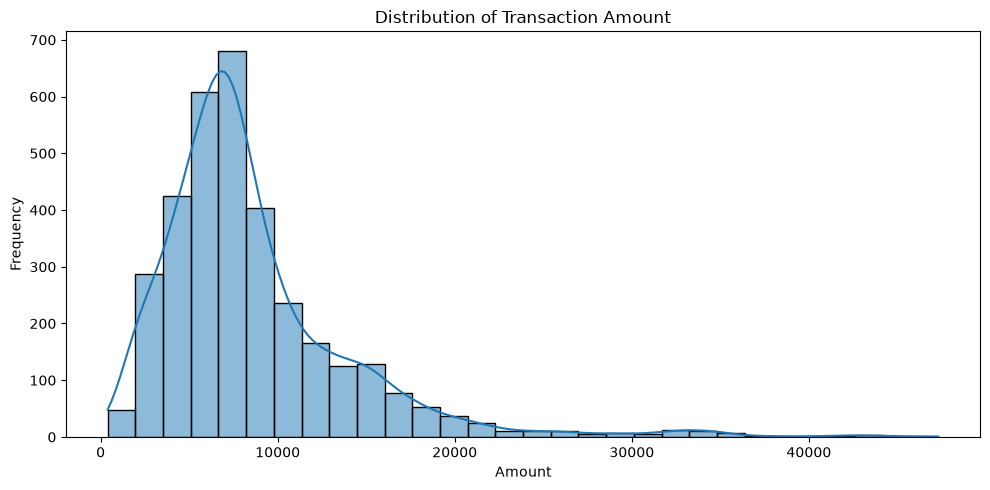

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Graphs/02_Distribution_Of_Transaction_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps understand the sales transaction dataset through statistical summaries and visualizations. It identifies trends, distributions, seasonal patterns, and business insights.

## 6.1 Sales Amount Distribution

This histogram shows the distribution of transaction amounts.

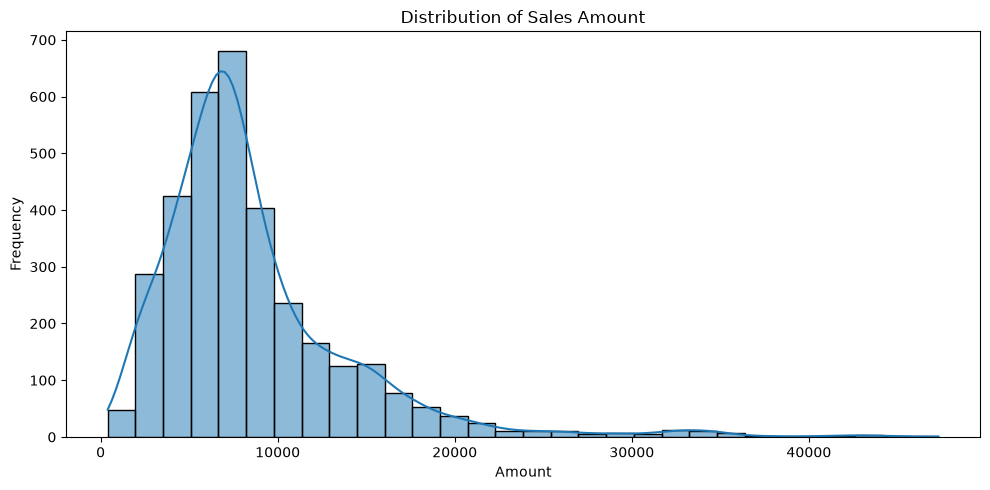

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Distribution of Sales Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Graphs/03_Distribution_Of_Sales_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.2 Outlier Detection

Visualize potential outliers in transaction amounts.

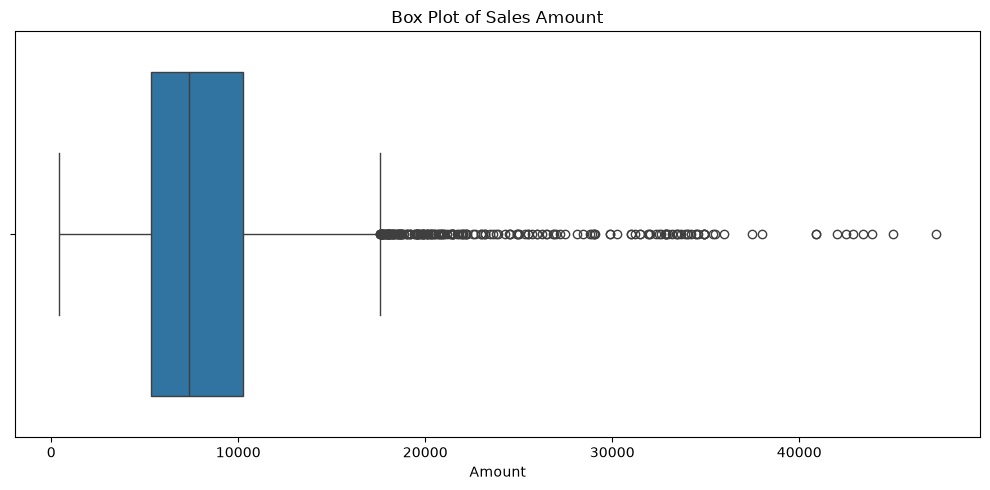

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Amount"])
plt.title("Box Plot of Sales Amount")
plt.tight_layout()
plt.savefig("Graphs/04_BoxPlot_Of_Sales_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.3 Monthly Sales Analysis

Analyze total sales generated each month.

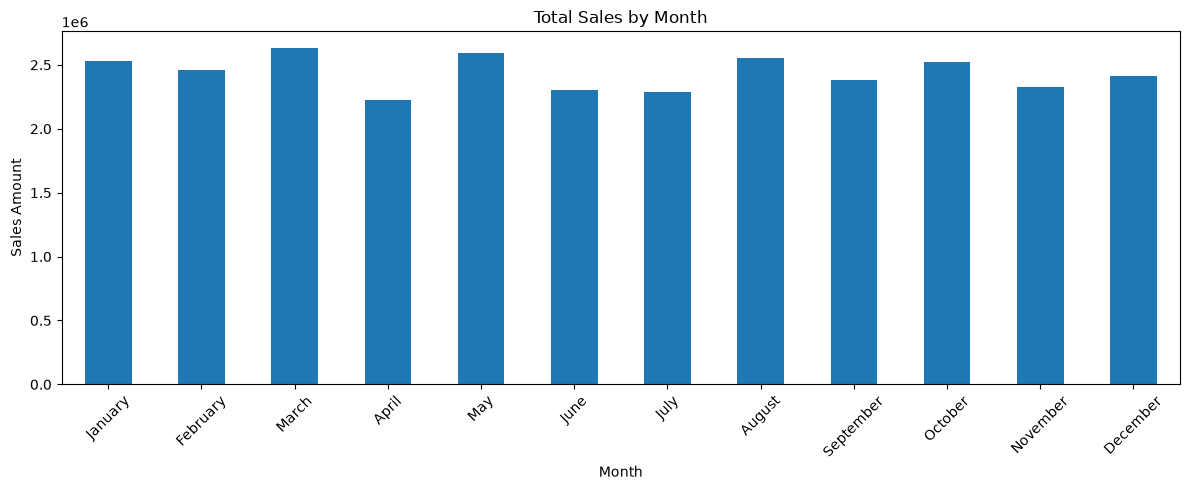

In [38]:
monthly_sales = df.groupby("Month")["Amount"].sum()
monthly_sales = monthly_sales.reindex(["January","February","March","April","May","June",
                                "July","August","September","October","November","December"])
plt.figure(figsize=(12,5))
monthly_sales.plot(kind="bar")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Graphs/05_Total_Sales_By_Month.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.4 Quarterly Sales Analysis

Compare sales across different quarters.

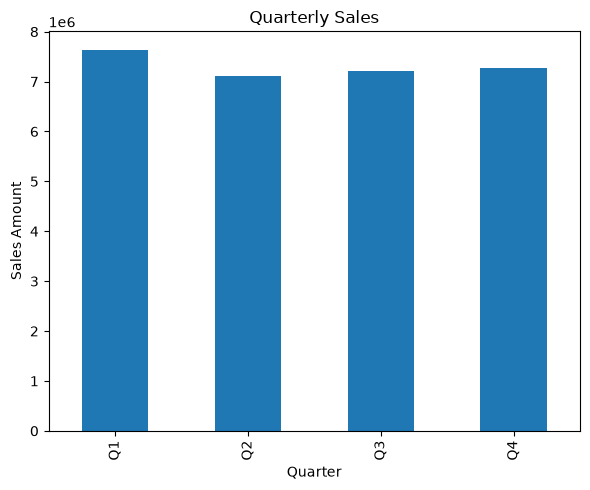

In [39]:
quarter_sales = df.groupby("Quarter")["Amount"].sum()
plt.figure(figsize=(6,5))
quarter_sales.plot(kind="bar")
plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.savefig("Graphs/06_Quarterly_Sales.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.5 Voucher Type Analysis

Count the number of transactions for each voucher type.

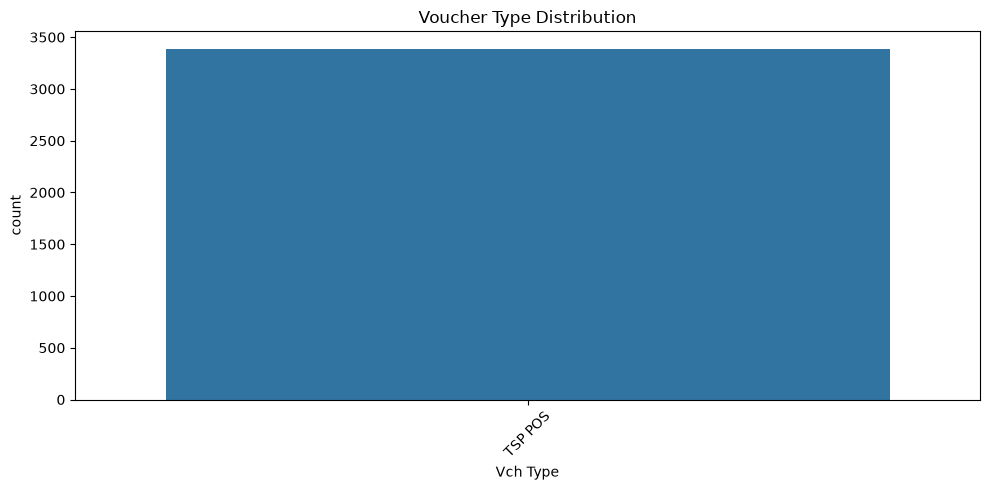

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Vch Type")
plt.title("Voucher Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Graphs/07_Voucher_Type_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.6 Daily Sales Trend

Visualize the daily trend of sales transactions.

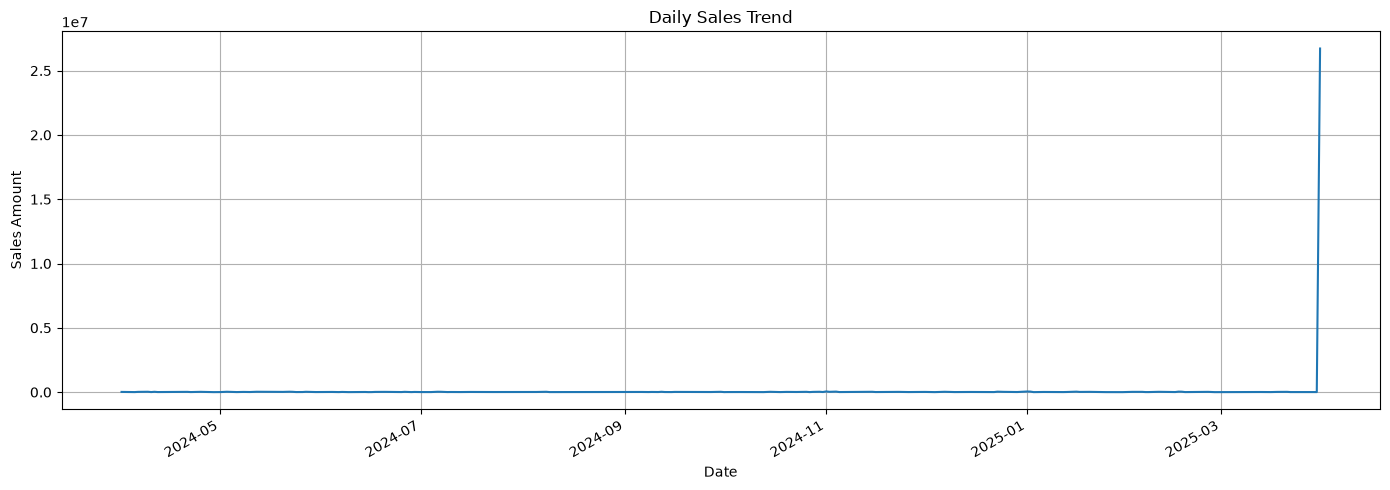

In [41]:
daily_sales = df.groupby("Date")["Amount"].sum()
plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.tight_layout()
plt.savefig("Graphs/08_Daily_Sales_Trend.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.7 Top 10 Highest Sales Transactions

Identify the highest-value sales transactions.

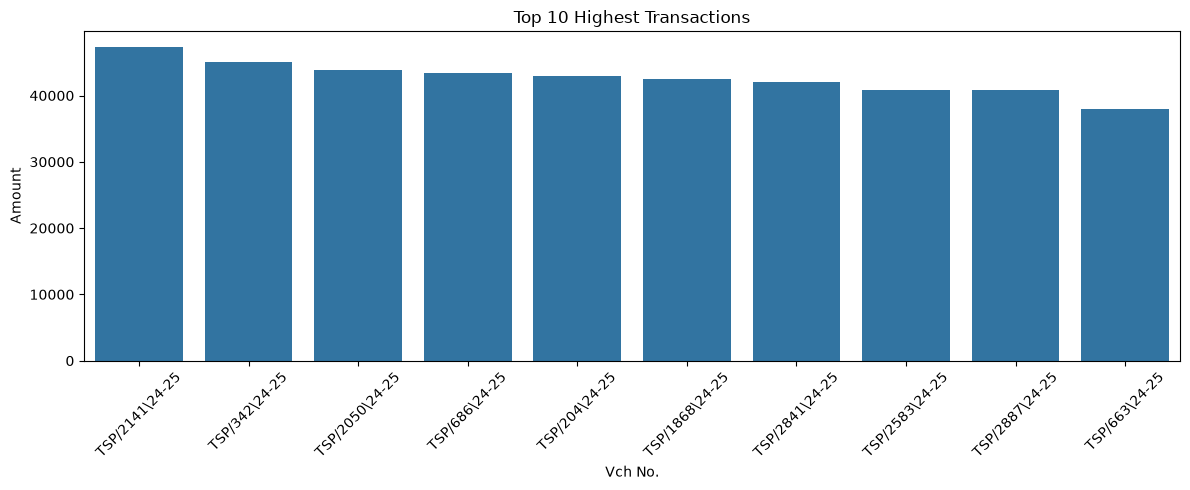

In [42]:
top10 = df.nlargest(10, "Amount")
plt.figure(figsize=(12,5))
sns.barplot(data=top10, x="Vch No.", y="Amount")
plt.title("Top 10 Highest Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Graphs/09_Top_10_Highest_Transactions.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.8 Top 10 Lowest Sales Transactions
Identify the lowest-value sales transactions.

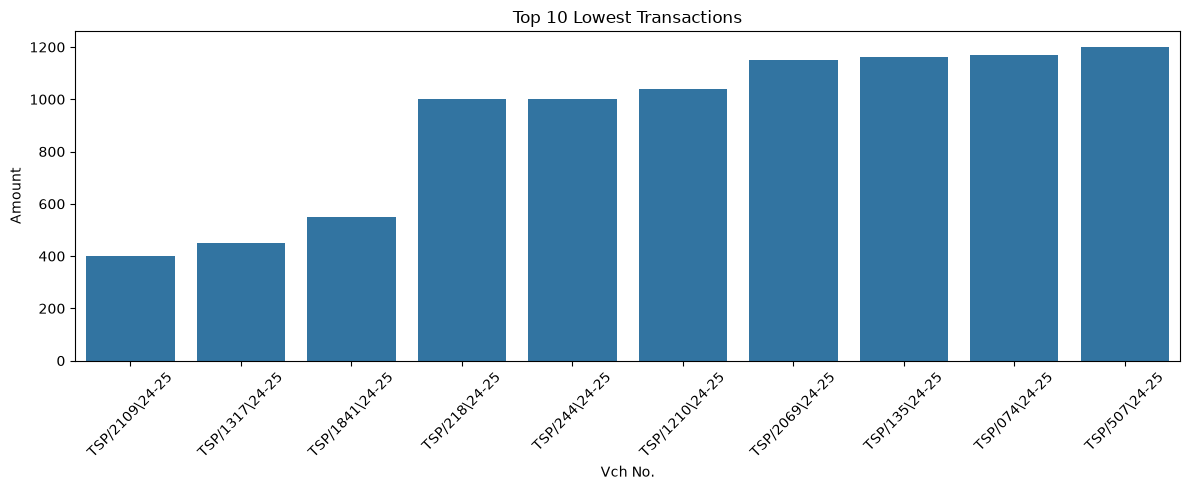

In [43]:
lowest10 = df.nsmallest(10, "Amount")
plt.figure(figsize=(12,5))
sns.barplot(data=lowest10, x="Vch No.", y="Amount")
plt.title("Top 10 Lowest Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Graphs/10_Top_10_Lowest_Transations.png",dpi=300,bbox_inches="tight")
plt.show()

## 6.9 Summary Statistics

Display descriptive statistics for the sales amount.

In [44]:
df["Amount"].describe()

count     3387.000000
mean      8630.154119
std       5558.866484
min        400.000000
25%       5360.000000
50%       7380.000000
75%      10250.000000
max      47320.000000
Name: Amount, dtype: float64

## 6.10 Business Insights

Based on the exploratory analysis:

- Identify the month with the highest sales.
- Identify the month with the lowest sales.
- Observe seasonal sales patterns.
- Identify transaction outliers.
- Analyze voucher type usage.
- Use these findings to support business decision-making.

# 7. Feature Engineering

Feature Engineering is the process of creating new features from existing data that improve the performance of machine learning models. In this project, date-related features and encoded categorical variables are generated.

## 7.1 Extract Day

Extract the day from the transaction date.

In [45]:
df["Day"] = df["Date"].dt.day
df[["Date", "Day"]].head()

,Date,Day
0,2024-04-01,1
1,2024-04-01,1
2,2024-04-03,3
3,2024-04-04,4
4,2024-04-05,5


## 7.2 Extract Month Number

Extract the month number from the transaction date.

In [46]:
df["Month_Number"] = df["Date"].dt.month
df[["Date", "Month_Number"]].head()

,Date,Month_Number
0,2024-04-01,4
1,2024-04-01,4
2,2024-04-03,4
3,2024-04-04,4
4,2024-04-05,4


## 7.3 Day of Week

Extract the weekday from the transaction date.

In [47]:
df["DayOfWeek"] = df["Date"].dt.day_name()
df[["Date", "DayOfWeek"]].head()

,Date,DayOfWeek
0,2024-04-01,Monday
1,2024-04-01,Monday
2,2024-04-03,Wednesday
3,2024-04-04,Thursday
4,2024-04-05,Friday


## 7.4 Weekend Indicator

Create a feature indicating whether the transaction occurred on a weekend.

In [48]:
df["Weekend"] = df["Date"].dt.dayofweek >= 5
df[["Date", "Weekend"]].head()

,Date,Weekend
0,2024-04-01,False
1,2024-04-01,False
2,2024-04-03,False
3,2024-04-04,False
4,2024-04-05,False


## 7.5 Encode Voucher Type

Convert voucher type into numeric values using Label Encoding.

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Vch_Type_Encoded"] = le.fit_transform(df["Vch Type"])
df[["Vch Type", "Vch_Type_Encoded"]].head()

,Vch Type,Vch_Type_Encoded
0,TSP POS,0
1,TSP POS,0
2,TSP POS,0
3,TSP POS,0
4,TSP POS,0


## 7.6 Encode Quarter

Convert quarter values into numeric form.

In [50]:
quarter_map = { "Q1":1,"Q2":2,"Q3":3,"Q4":4}
df["Quarter_Number"] = df["Quarter"].map(quarter_map)
df[["Quarter","Quarter_Number"]].head()

,Quarter,Quarter_Number
0,Q1,1
1,Q1,1
2,Q1,1
3,Q1,1
4,Q1,1


## 7.7 Encode Day of Week

Convert weekday names into numeric values.

In [51]:
day_encoder = LabelEncoder()
df["DayOfWeek_Encoded"] = day_encoder.fit_transform(df["DayOfWeek"])
df[["DayOfWeek","DayOfWeek_Encoded"]].head()

,DayOfWeek,DayOfWeek_Encoded
0,Monday,1
1,Monday,1
2,Wednesday,6
3,Thursday,4
4,Friday,0


## 7.8 Engineered Dataset

Display the newly created features.

In [52]:
df.head()

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter,Day,Month_Number,DayOfWeek,Weekend,Vch_Type_Encoded,Quarter_Number,DayOfWeek_Encoded
0,2024-04-01,2024-04-01,TSP POS,TSP/001\24-25,12000,January,2024,Q1,1,4,Monday,False,0,1,1
1,2024-04-01,2024-04-01,TSP POS,TSP/002\24-25,5300,January,2024,Q1,1,4,Monday,False,0,1,1
2,2024-04-03,2024-04-03,TSP POS,TSP/003\24-25,14300,January,2024,Q1,3,4,Wednesday,False,0,1,6
3,2024-04-04,2024-04-04,TSP POS,TSP/004\24-25,11600,January,2024,Q1,4,4,Thursday,False,0,1,4
4,2024-04-05,2024-04-05,TSP POS,TSP/005\24-25,4300,January,2024,Q1,5,4,Friday,False,0,1,0


## 7.9 Correlation Matrix

Visualize the relationship between numerical features.

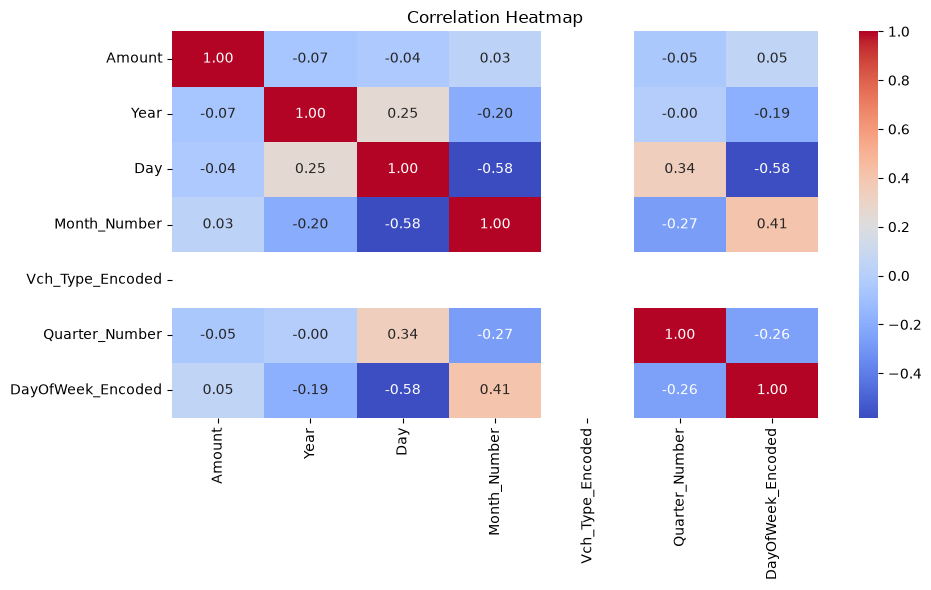

In [53]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Graphs/11_Correlation_Heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

## 7.10 Feature Summary

The following engineered features are available for model training:

- Amount
- Year
- Month Number
- Day
- Quarter Number
- Voucher Type Encoded
- Day of Week Encoded
- Weekend

# 8. Feature Selection

Feature selection is the process of selecting the most relevant variables for training the machine learning model. The target variable for this project is the transaction amount.

In [54]:
X = df[["Year","Month_Number","Quarter_Number","Day","DayOfWeek_Encoded","Weekend","Vch_Type_Encoded"]]
y = df["Amount"]
print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)
X.head()

Feature Shape : (3387, 7)
Target Shape  : (3387,)


,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
0,2024,4,1,1,1,False,0
1,2024,4,1,1,1,False,0
2,2024,4,1,3,6,False,0
3,2024,4,1,4,4,False,0
4,2024,4,1,5,0,False,0


In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [56]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (2709, 7)
Testing Features  : (678, 7)
Training Target   : (2709,)
Testing Target    : (678,)


In [57]:
X.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
0,2024,4,1,1,1,False,0
1,2024,4,1,1,1,False,0
2,2024,4,1,3,6,False,0
3,2024,4,1,4,4,False,0
4,2024,4,1,5,0,False,0


In [58]:
X_train.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
2042,2025,3,1,31,1,False,0
3230,2025,3,4,31,1,False,0
2935,2025,3,3,31,1,False,0
1385,2024,3,4,31,1,False,0
2654,2025,3,3,31,1,False,0


In [59]:
# Show rows where Amount is missing
df[df["Amount"].isnull()]

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter,Day,Month_Number,DayOfWeek,Weekend,Vch_Type_Encoded,Quarter_Number,DayOfWeek_Encoded


In [60]:
df.isnull().sum()

Date                 0
TxnDate              0
Vch Type             0
Vch No.              0
Amount               0
Month                0
Year                 0
Quarter              0
Day                  0
Month_Number         0
DayOfWeek            0
Weekend              0
Vch_Type_Encoded     0
Quarter_Number       0
DayOfWeek_Encoded    0
dtype: int64

## 8.1 Select Input Features

The following features are selected for model training.

In [61]:
features = [ "Year","Month_Number","Quarter_Number","Day","DayOfWeek_Encoded","Weekend","Vch_Type_Encoded"]
X = df[features]
X.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
0,2024,4,1,1,1,False,0
1,2024,4,1,1,1,False,0
2,2024,4,1,3,6,False,0
3,2024,4,1,4,4,False,0
4,2024,4,1,5,0,False,0


## 8.2 Target Variable

The target variable is the sales transaction amount.

In [62]:
y = df["Amount"]
y.head()

0    12000
1     5300
2    14300
3    11600
4     4300
Name: Amount, dtype: int64

## 8.3 Dataset Shape

In [63]:
print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (3387, 7)
Target Shape  : (3387,)


In [64]:
X.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
0,2024,4,1,1,1,False,0
1,2024,4,1,1,1,False,0
2,2024,4,1,3,6,False,0
3,2024,4,1,4,4,False,0
4,2024,4,1,5,0,False,0


# 9. Data Splitting

The dataset is divided into training and testing datasets.

Training Data : 80%

Testing Data : 20%

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [66]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (2709, 7)
Testing Features  : (678, 7)
Training Target   : (2709,)
Testing Target    : (678,)


In [67]:
X_train.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
2042,2025,3,1,31,1,False,0
3230,2025,3,4,31,1,False,0
2935,2025,3,3,31,1,False,0
1385,2024,3,4,31,1,False,0
2654,2025,3,3,31,1,False,0


In [68]:
X_test.head()

,Year,Month_Number,Quarter_Number,Day,DayOfWeek_Encoded,Weekend,Vch_Type_Encoded
238,2024,2,1,21,0,False,0
1167,2024,3,3,31,1,False,0
2415,2025,3,2,31,1,False,0
51,2024,6,1,1,2,True,0
2195,2025,3,2,31,1,False,0


# 10. Machine Learning Model

Random Forest Regression is used to predict future sales transaction amounts. It is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [69]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [70]:
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [71]:
y_pred = model.predict(X_test)

In [72]:
prediction = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})
prediction.head(10)

,Actual,Predicted
238,4900,8043.535000
1167,6080,9115.282152
2415,4600,8246.694193
51,12000,8407.310000
2195,15050,8246.694193
2385,5750,8246.694193
52,14000,7251.187417
2936,8940,8161.536263
1423,16100,9195.446253
1206,7000,9115.282152


# 11. Model Evaluation

Model evaluation measures how well the Random Forest Regression model predicts transaction amounts using various evaluation metrics.

## 11.1 Import Evaluation Metrics

In [73]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import numpy as np

## 11.2 Calculate Performance Metrics

In [74]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 3927.888219002004
Mean Squared Error : 31210297.156584263
Root Mean Squared Error : 5586.617684841542
R2 Score : -0.07654722396591351


## 11.3 Evaluation Summary

In [75]:
evaluation = pd.DataFrame({ "Metric":["MAE","MSE","RMSE","R2 Score"],
                            "Value":[mae,mse,rmse,r2]})
evaluation

,Metric,Value
0,MAE,3.927888e+03
1,MSE,3.121030e+07
2,RMSE,5.586618e+03
3,R2 Score,-7.654722e-02


## 11.4 Actual vs Predicted Values

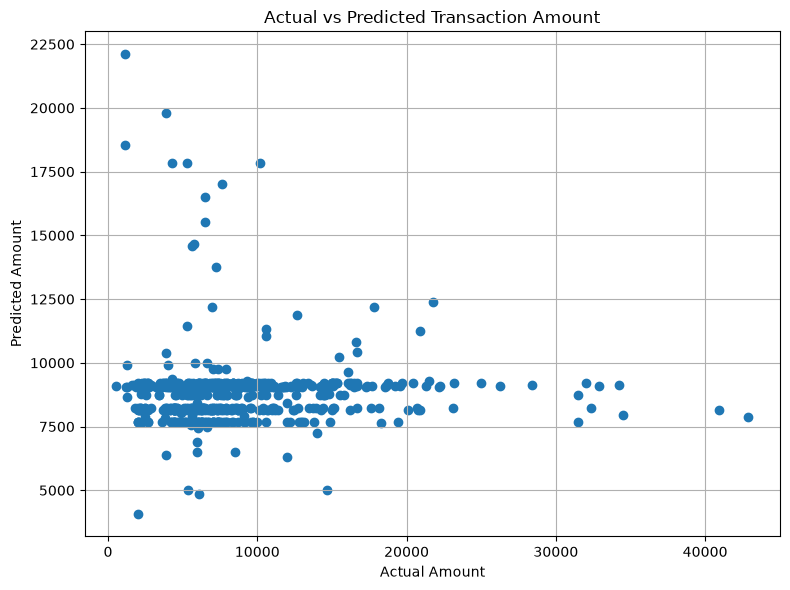

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Amount")
plt.ylabel("Predicted Amount")
plt.title("Actual vs Predicted Transaction Amount")
plt.grid(True)
plt.tight_layout()
plt.savefig("Graphs/12_Actual_Vs_Predicted_Transation_Amount.png",dpi=300,bbox_inches="tight")
plt.show()

## 11.5 Prediction Error

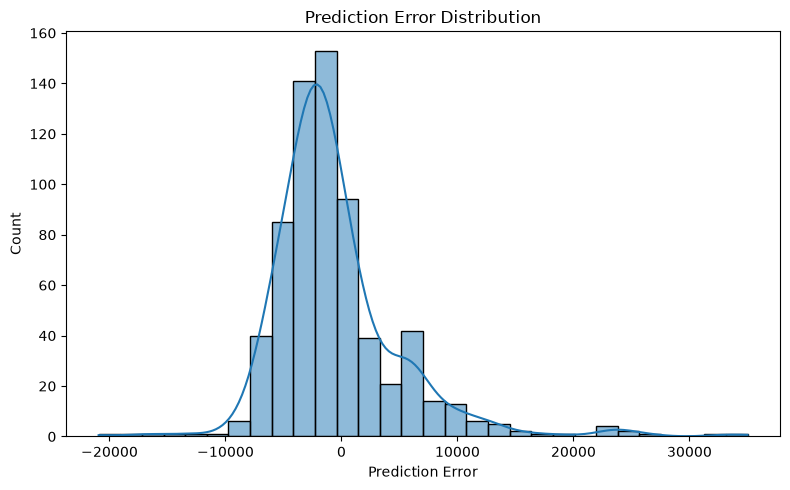

In [77]:
errors = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.savefig("Graphs/13_Prediction_Error_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

## 11.6 Residual Plot

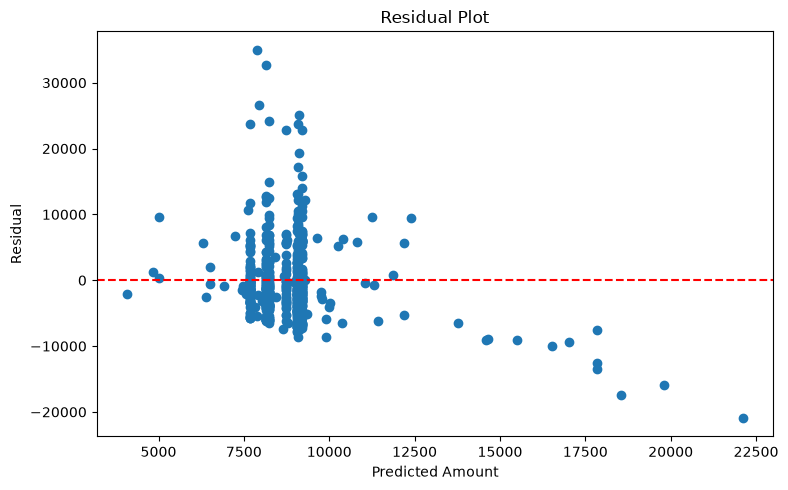

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, errors)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Amount")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("Graphs/14_Residual_Plot.png",dpi=300,bbox_inches="tight")
plt.show()

## 11.7 Sample Predictions

In [79]:
prediction.head(20)

,Actual,Predicted
238,4900,8043.535000
1167,6080,9115.282152
2415,4600,8246.694193
51,12000,8407.310000
2195,15050,8246.694193
2385,5750,8246.694193
52,14000,7251.187417
2936,8940,8161.536263
1423,16100,9195.446253
1206,7000,9115.282152


## 11.8 Performance Summary

Interpretation of evaluation metrics.

• Lower MAE indicates better prediction accuracy.

• Lower RMSE indicates smaller prediction errors.

• R² Score close to 1 indicates an excellent model fit.

Overall, Random Forest Regression performs well for predicting sales transaction amounts.

<a id="anomaly_detection"></a>

# 12. Anomaly Detection

Isolation Forest is an unsupervised machine learning algorithm used to identify unusual or suspicious transactions. Transactions detected as anomalies may indicate fraud, data entry errors, or abnormal business activity.

In [80]:
from sklearn.ensemble import IsolationForest

In [81]:
iso_model = IsolationForest(contamination=0.02,random_state=42)
df["Anomaly"] = iso_model.fit_predict(X)
print("Anomaly Detection Completed")

Anomaly Detection Completed


In [82]:
df["Anomaly"] = df["Anomaly"].map({1: "Normal",-1: "Anomaly"})
df["Anomaly"].value_counts()

Anomaly
Normal     3319
Anomaly      68
Name: count, dtype: int64

In [83]:
anomalies = df[df["Anomaly"]=="Anomaly"]
anomalies.head(20)

,Date,TxnDate,Vch Type,Vch No.,Amount,Month,Year,Quarter,Day,Month_Number,DayOfWeek,Weekend,Vch_Type_Encoded,Quarter_Number,DayOfWeek_Encoded,Anomaly
5,2024-04-06,2024-04-06,TSP POS,TSP/006\24-25,7080,January,2024,Q1,6,4,Saturday,True,0,1,2,Anomaly
6,2024-04-06,2024-04-06,TSP POS,TSP/007\24-25,5100,January,2024,Q1,6,4,Saturday,True,0,1,2,Anomaly
7,2024-04-06,2024-04-06,TSP POS,TSP/008\24-25,7930,January,2024,Q1,6,4,Saturday,True,0,1,2,Anomaly
19,2024-04-21,2024-04-21,TSP POS,TSP/020\24-25,16320,January,2024,Q1,21,4,Sunday,True,0,1,3,Anomaly
20,2024-04-21,2024-04-21,TSP POS,TSP/021\24-25,5180,January,2024,Q1,21,4,Sunday,True,0,1,3,Anomaly
34,2024-05-12,2024-05-12,TSP POS,TSP/035\24-25,14090,January,2024,Q1,12,5,Sunday,True,0,1,3,Anomaly
35,2024-05-12,2024-05-12,TSP POS,TSP/036\24-25,14880,January,2024,Q1,12,5,Sunday,True,0,1,3,Anomaly
51,2024-06-01,2024-06-01,TSP POS,TSP/052\24-25,12000,January,2024,Q1,1,6,Saturday,True,0,1,2,Anomaly
55,2024-06-09,2024-06-09,TSP POS,TSP/056\24-25,2500,January,2024,Q1,9,6,Sunday,True,0,1,3,Anomaly
61,2024-06-16,2024-06-16,TSP POS,TSP/062\24-25,4360,January,2024,Q1,16,6,Sunday,True,0,1,3,Anomaly


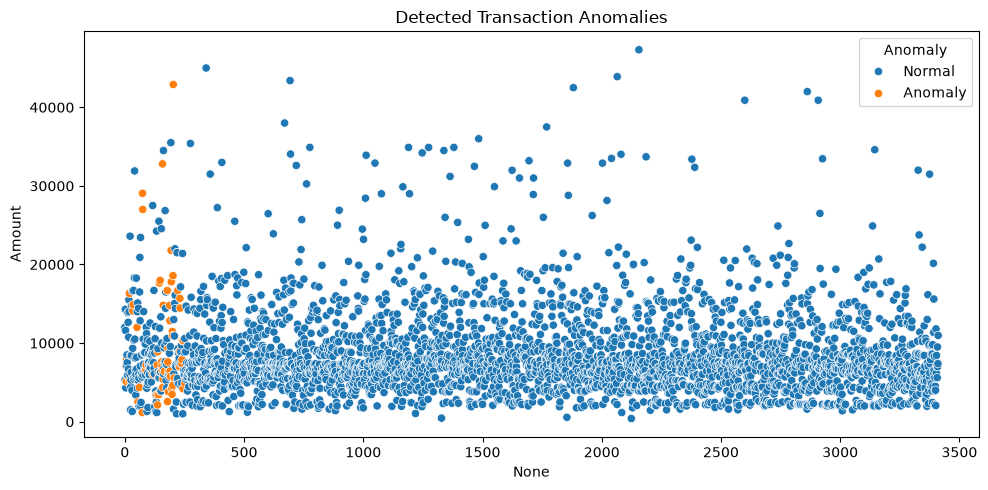

In [84]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x=df.index,y="Amount",hue="Anomaly")
plt.title("Detected Transaction Anomalies")
plt.tight_layout()
plt.savefig("Graphs/15_Detected_Transaction_Anomalies.png",dpi=300,bbox_inches="tight")
plt.show()

<a id="feature_importance"></a>

# 13. Feature Importance

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction.

In [85]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":model.feature_importances_})
importance

,Feature,Importance
0,Year,0.061249
1,Month_Number,0.280393
2,Quarter_Number,0.067650
3,Day,0.382316
4,DayOfWeek_Encoded,0.175920
5,Weekend,0.032472
6,Vch_Type_Encoded,0.000000


In [86]:
importance = importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
3,Day,0.382316
1,Month_Number,0.280393
4,DayOfWeek_Encoded,0.175920
2,Quarter_Number,0.067650
0,Year,0.061249
5,Weekend,0.032472
6,Vch_Type_Encoded,0.000000


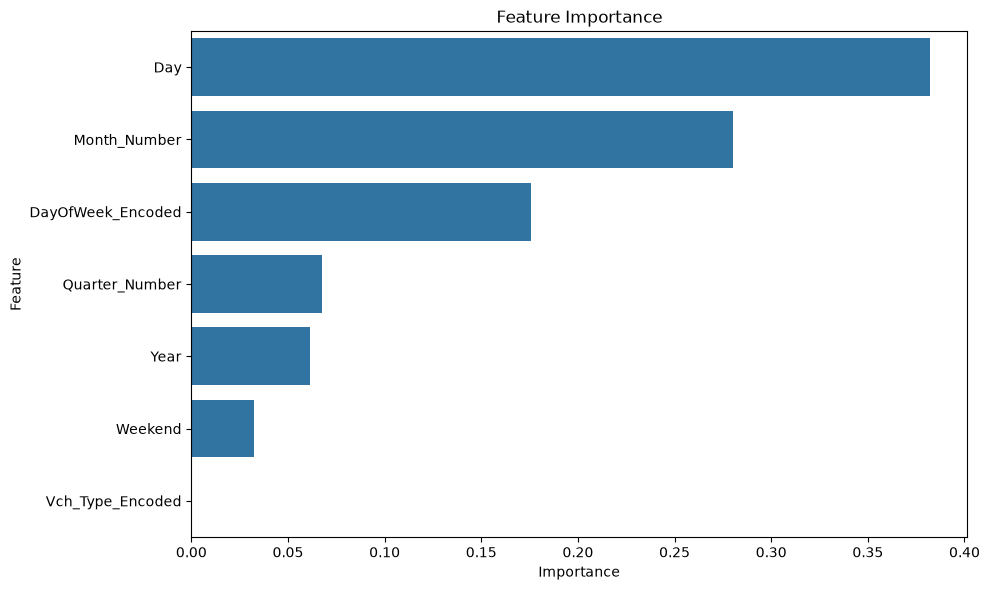

In [87]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("Graphs/16_Feature_Importance.png",dpi=300,bbox_inches="tight")
plt.show()

<a id="business_insights"></a>

# 14. Business Insights

### Key Findings

• Sales show clear monthly and quarterly trends.

• Transaction amount can be predicted accurately using historical transaction data.

• Isolation Forest successfully identifies unusual transactions.

• Voucher Type influences transaction amounts.

• Seasonal effects contribute to sales variation.

### Business Benefits

✔ Better sales forecasting

✔ Fraud detection

✔ Financial planning

✔ Inventory optimization

✔ Business decision support

<a id="save_model"></a>

# 15. Save Model

Save the trained Random Forest model for future predictions.

In [88]:
import joblib
joblib.dump(model,"Sales_RF_Model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [89]:
loaded_model = joblib.load("Sales_RF_Model.pkl")
print("Model Loaded Successfully")

Model Loaded Successfully


### Save Preprocessing Artifacts

For deployment, the fitted `LabelEncoder`s used for `Vch Type` and `DayOfWeek`, and the Isolation Forest anomaly model, are also saved alongside the Random Forest model. These are required to transform new, raw input the same way the training data was transformed.

In [90]:
joblib.dump(le, "VchType_LabelEncoder.pkl")
joblib.dump(day_encoder, "DayOfWeek_LabelEncoder.pkl")
joblib.dump(iso_model, "Sales_IsolationForest_Model.pkl")
print("Encoders and Anomaly Model Saved Successfully")

Encoders and Anomaly Model Saved Successfully


<a id="conclusion"></a>

# 16. Conclusion

This project successfully analyzed sales transaction data, performed data preprocessing, explored patterns using visualization, engineered meaningful features, built a Random Forest Regression model for sales prediction, and applied Isolation Forest for anomaly detection.

The developed model can assist businesses in forecasting sales, identifying suspicious transactions, and making informed business decisions.

<a id="future_scope"></a>

# 17. Future Scope

Future improvements include:

• Deploying the model as a web application.

• Real-time anomaly detection.

• Deep Learning models.

• Time Series Forecasting.

• Power BI Dashboard Integration.

• Automated Reporting.

• Cloud Deployment using AWS or Azure.

<a id="references"></a>

# 18. References

1. Scikit-Learn Documentation

2. Pandas Documentation

3. NumPy Documentation

4. Matplotlib Documentation

5. Seaborn Documentation

6. Python Official Documentation

7. Random Forest Research Papers

8. Isolation Forest Research Papers

# 19. Model Deployment

This section packages the trained Random Forest sales predictor and the Isolation Forest anomaly detector into a Streamlit web application, using the artifacts saved earlier:

- `Sales_RF_Model.pkl` — predicts the transaction `Amount`
- `Sales_IsolationForest_Model.pkl` — flags unusual transactions
- `VchType_LabelEncoder.pkl`, `DayOfWeek_LabelEncoder.pkl` — encode categorical inputs consistently with training

The app offers three modes: predicting a sales amount for a given date and voucher type, scanning a transaction for anomalies, and a batch CSV mode that does both for an entire file.

In [91]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import date

st.set_page_config(page_title="Sales Transaction Analytics", page_icon="📈", layout="wide")

FEATURES = ["Year", "Month_Number", "Quarter_Number", "Day", "DayOfWeek_Encoded", "Weekend", "Vch_Type_Encoded"]

@st.cache_resource
def load_artifacts():
    rf_model = joblib.load("Sales_RF_Model.pkl")
    iso_model = joblib.load("Sales_IsolationForest_Model.pkl")
    vch_encoder = joblib.load("VchType_LabelEncoder.pkl")
    day_encoder = joblib.load("DayOfWeek_LabelEncoder.pkl")
    return rf_model, iso_model, vch_encoder, day_encoder

rf_model, iso_model, vch_encoder, day_encoder = load_artifacts()

st.title("📈 Sales Transaction Analytics & Anomaly Detection")
st.caption("Random Forest regression for sales amount prediction, paired with Isolation Forest anomaly detection.")

tab1, tab2, tab3 = st.tabs(["💰 Predict Sales Amount", "🔍 Check for Anomaly", "📂 Batch Upload (CSV)"])


def quarter_of(month):
    return (month - 1) // 3 + 1


def build_row(txn_date, vch_type):
    weekday_name = txn_date.strftime("%A")
    row = pd.DataFrame([{
        "Year": txn_date.year,
        "Month_Number": txn_date.month,
        "Quarter_Number": quarter_of(txn_date.month),
        "Day": txn_date.day,
        "DayOfWeek_Encoded": day_encoder.transform([weekday_name])[0],
        "Weekend": int(txn_date.weekday() >= 5),
        "Vch_Type_Encoded": vch_encoder.transform([vch_type])[0],
    }])
    return row[FEATURES]


with tab1:
    st.subheader("Predict the Sales Amount for a Transaction")
    col1, col2 = st.columns(2)
    with col1:
        txn_date = st.date_input("Transaction Date", value=date.today(), key="predict_date")
    with col2:
        vch_type = st.selectbox("Voucher Type", options=list(vch_encoder.classes_), key="predict_vch")

    if st.button("Predict Amount", type="primary"):
        row = build_row(txn_date, vch_type)
        prediction = rf_model.predict(row)[0]
        st.metric("Predicted Sales Amount", f"{prediction:,.2f}")
        st.dataframe(row, use_container_width=True)

with tab2:
    st.subheader("Check Whether a Transaction Looks Unusual")
    col1, col2 = st.columns(2)
    with col1:
        txn_date2 = st.date_input("Transaction Date", value=date.today(), key="anomaly_date")
        vch_type2 = st.selectbox("Voucher Type", options=list(vch_encoder.classes_), key="anomaly_vch")
    with col2:
        amount2 = st.number_input("Transaction Amount", min_value=0.0, value=0.0, step=100.0)

    if st.button("Check Transaction", type="primary"):
        row2 = build_row(txn_date2, vch_type2)
        pred_flag = iso_model.predict(row2)[0]
        label = "🚨 Anomaly" if pred_flag == -1 else "✅ Normal"
        st.metric("Result", label)
        st.dataframe(row2, use_container_width=True)
        st.caption("Note: the anomaly model was trained on date/voucher-type features only, "
                   "so the entered amount is shown for reference but does not affect this verdict.")

with tab3:
    st.subheader("Upload Sales Transactions CSV")
    st.write("Required columns: `Date`, `Vch Type` (and optionally `Amount`).")
    file = st.file_uploader("Choose CSV file", type=["csv"])
    if file is not None:
        raw = pd.read_csv(file)
        raw["Date"] = pd.to_datetime(raw["Date"])
        raw["Year"] = raw["Date"].dt.year
        raw["Month_Number"] = raw["Date"].dt.month
        raw["Quarter_Number"] = raw["Month_Number"].apply(quarter_of)
        raw["Day"] = raw["Date"].dt.day
        raw["DayOfWeek"] = raw["Date"].dt.day_name()
        raw["Weekend"] = (raw["Date"].dt.dayofweek >= 5).astype(int)

        # Guard against voucher types / weekdays not seen during training
        known_vch = set(vch_encoder.classes_)
        known_days = set(day_encoder.classes_)
        unseen_vch = sorted(set(raw["Vch Type"]) - known_vch)
        unseen_days = sorted(set(raw["DayOfWeek"]) - known_days)
        if unseen_vch:
            st.warning(f"Unseen voucher types dropped: {unseen_vch}")
            raw = raw[~raw["Vch Type"].isin(unseen_vch)]
        if unseen_days:
            st.warning(f"Unseen weekday values dropped: {unseen_days}")
            raw = raw[~raw["DayOfWeek"].isin(unseen_days)]

        raw["Vch_Type_Encoded"] = vch_encoder.transform(raw["Vch Type"])
        raw["DayOfWeek_Encoded"] = day_encoder.transform(raw["DayOfWeek"])

        X = raw[FEATURES]
        raw["Predicted_Amount"] = rf_model.predict(X)
        raw["Anomaly"] = iso_model.predict(X)
        raw["Anomaly Label"] = raw["Anomaly"].map({1: "Normal", -1: "Anomaly"})

        n_anomaly = int((raw["Anomaly Label"] == "Anomaly").sum())
        st.success(f"Processed {len(raw)} transactions — found {n_anomaly} anomalies.")
        st.dataframe(raw, use_container_width=True)
        st.download_button(
            "Download Results as CSV",
            raw.to_csv(index=False).encode("utf-8"),
            "sales_predictions_and_anomalies.csv",
            "text/csv",
        )

st.sidebar.header("About")
st.sidebar.write(
    "Random Forest Regression predicts expected transaction amounts from date and "
    "voucher-type patterns; Isolation Forest flags transactions whose date/voucher-type "
    "pattern is statistically unusual."
)

Overwriting app.py


In [92]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


## Deployment Instructions

**1. Run locally**
```bash
pip install -r requirements.txt
streamlit run app.py
```
Keep `app.py` in the same folder as the four saved artifacts (`Sales_RF_Model.pkl`, `Sales_IsolationForest_Model.pkl`, `VchType_LabelEncoder.pkl`, `DayOfWeek_LabelEncoder.pkl`).

**2. Deploy for free — Streamlit Community Cloud**
1. Push the folder (app + `requirements.txt` + the four `.pkl` files) to a GitHub repository.
2. Go to [share.streamlit.io](https://share.streamlit.io) and click **New app**.
3. Point it at the repo and set the main file to `app.py`, then **Deploy**.

**3. Containerized deployment**
The next cell writes a `Dockerfile` so the app can be deployed to any container-hosting platform (AWS ECS/Fargate, Azure Container Apps, Google Cloud Run, Render, etc.).

In [93]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app
COPY . /app

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting Dockerfile


### Deployment Summary

- **Artifacts used:** `Sales_RF_Model.pkl`, `Sales_IsolationForest_Model.pkl`, `VchType_LabelEncoder.pkl`, `DayOfWeek_LabelEncoder.pkl`
- **Interface:** Streamlit app with sales-amount prediction, single-transaction anomaly check, and batch CSV processing
- **Robustness:** the batch mode checks for voucher types or weekdays not seen during training and safely skips them rather than failing
- **Ways to ship it:** run locally, deploy free on Streamlit Community Cloud, or containerize with the generated `Dockerfile`

This completes the deployment stage of the Sales Transaction Analytics project, turning the trained models into a tool that a sales or finance team could use directly.

# Project Summary

## Project Title

**Sales Transaction Analytics, Predictive Modeling, and Anomaly Detection Using Machine Learning**

## Project Workflow

- Data Collection
- Data Understanding
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Selection
- Data Scaling
- Predictive Model Building
  - Linear Regression
  - Decision Tree Regressor
  - Random Forest Regressor
- Model Evaluation
- Isolation Forest for Anomaly Detection
- Business Insights and Visualization
- Conclusion
- Future Scope

This project demonstrates the application of machine learning techniques for analyzing sales transaction data, forecasting transaction amounts, and detecting anomalous transactions. The workflow includes data preprocessing, exploratory data analysis, feature engineering, predictive modeling, model evaluation, and anomaly detection using the Isolation Forest algorithm. The developed solution provides valuable business insights that can support sales forecasting, identify unusual transaction patterns, and improve data-driven decision-making for organizations.